# BiGRU + Conv1D with GWO Hyperparameter Optimisation
## Unified Pipeline: Baseline → GWO Search → Optimised Final Training




## 1. Environment & Imports

In [1]:
# ============================================================
# 1.1  Environment Variables
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"         # suppress TF C++ logs
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"        # deterministic ops
os.environ["CUDA_VISIBLE_DEVICES"]  = "0"      # adjust as needed

# ============================================================
# 1.2  Imports
# ============================================================
import warnings, random, time
from datetime import timedelta
from typing import Dict, List, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, BatchNormalization, MaxPooling1D,
    GRU, Bidirectional, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# mealpy >= 3.0  (pip install mealpy)
from mealpy.swarm_based.GWO import OriginalGWO
from mealpy.utils.space import IntegerVar, FloatVar

print("\u2713 All imports successful")
print(f"  TensorFlow : {tf.__version__}")
print(f"  NumPy      : {np.__version__}")

2026-03-29 20:44:02.138354: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-29 20:44:02.138752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-29 20:44:02.267796: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ All imports successful
  TensorFlow : 2.15.0
  NumPy      : 1.26.0


## 2. Global Configuration

In [2]:
# ============================================================
# 2.1  Paths
# ============================================================
DATA_PATHS: Dict[str, str] = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "val"  : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx",
    "test" : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
}

MODEL_DIR   = "./models"
RESULTS_DIR = "./results"
PLOTS_DIR   = "./plots"
GWO_DIR     = "./gwo_results"

for d in (MODEL_DIR, RESULTS_DIR, PLOTS_DIR, GWO_DIR):
    os.makedirs(d, exist_ok=True)

# ============================================================
# 2.2  Training Constants
# ============================================================
MODEL_NAME   = "BiGRU_Conv"
RANDOM_STATE = 116
EPOCHS       = 100     # full run; EarlyStopping will cut short
PATIENCE     = 5

# Baseline reference parameters (fixed, for comparison)
BASELINE_PARAMS: Dict = {
    "gru_units"    : 64,
    "cnn_filters"  : 64,
    "dropout"      : 0.3,
    "learning_rate": 3e-4,
    "batch_size"   : 256,
}

# ============================================================
# 2.3  GWO Configuration
# ============================================================
GWO_CONFIG: Dict = {
    "pop_size"   : 10,
    "epoch"      : 10,   # total evaluations ≈ pop_size × epoch
    "fit_epochs" : 30,   # reduced epochs per GWO fitness call
    "fit_patience": 3,   # early-stop patience during search
}

print(f"\u2713 Configuration ready  |  model={MODEL_NAME}  |  seed={RANDOM_STATE}")

✓ Configuration ready  |  model=BiGRU_Conv  |  seed=116


## 3. Reproducibility & GPU Setup

In [3]:
# ============================================================
# 3.1  Seed Utility
# ============================================================
def set_seeds(seed: int = RANDOM_STATE) -> None:
    """Fix all random seeds for reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# ============================================================
# 3.2  GPU Memory-Growth
# ============================================================
def setup_gpu() -> None:
    """Enable memory growth so TF does not grab all VRAM upfront."""
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print("  \u26a0  No GPU detected \u2013 running on CPU.")
        return
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical = tf.config.list_logical_devices("GPU")
        print(f"  \u2713  {len(gpus)} physical GPU(s) | {len(logical)} logical GPU(s)")
    except RuntimeError as exc:
        print(f"  \u26a0  GPU setup error: {exc}")


set_seeds()
setup_gpu()
print("\u2713 Reproducibility and GPU configuration complete.")

  ✓  1 physical GPU(s) | 1 logical GPU(s)
✓ Reproducibility and GPU configuration complete.


## 4. Data Loading

In [4]:
# ============================================================
# 4.1  Loader
# ============================================================
def load_dataset(path: str, split: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load an Excel dataset.

    Expects columns: [feature_0, ..., feature_n, labels]

    Returns
    -------
    X : (n_samples, seq_len)   y : (n_samples,)
    """
    df = pd.read_excel(path)
    X  = df.drop(columns="labels").values
    y  = df["labels"].values
    print(f"  {split.upper():5s} -> X={X.shape}  y={y.shape}  "
          f"class counts={np.bincount(y.astype(int))}")
    return X, y


# ============================================================
# 4.2  Load All Splits Once (shared by GWO objective)
# ============================================================
print("Loading datasets \u2026")
X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_val,   y_val   = load_dataset(DATA_PATHS["val"],   "val")
X_test,  y_test  = load_dataset(DATA_PATHS["test"],  "test")

VOCAB_SIZE = int(max(X_train.max(), X_val.max(), X_test.max()))
MAX_LEN    = int(X_train.shape[1])

print(f"\n\u2713 Vocab size : {VOCAB_SIZE}")
print(f"\u2713 Seq length : {MAX_LEN}")
print("\u2713 Data loaded once \u2013 will be reused for GWO.")

Loading datasets …
  TRAIN -> X=(8260, 271)  y=(8260,)  class counts=[4167 4093]
  VAL   -> X=(1806, 271)  y=(1806,)  class counts=[893 913]
  TEST  -> X=(1833, 271)  y=(1833,)  class counts=[893 940]

✓ Vocab size : 132
✓ Seq length : 271
✓ Data loaded once – will be reused for GWO.


## 5. Model Architecture

In [ ]:
# ============================================================
# 5.1  Model Builder
# ============================================================
def build_model(
    gru_units    : int   = 64,
    cnn_filters  : int   = 64,
    dropout      : float = 0.3,
    learning_rate: float = 3e-4,
    kernel_size  : int   = 5,
) -> Sequential:
    
    # coerce types (safe for direct calls and GWO callbacks)
    gru_units     = max(2,  int(round(float(gru_units))))
    cnn_filters   = max(1,  int(round(float(cnn_filters))))
    dropout       = float(np.clip(float(dropout), 0.0, 0.9))
    learning_rate = float(learning_rate)
    kernel_size   = int(kernel_size)

    set_seeds()   # deterministic weight initialisation

    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE + 1,
            output_dim=128,
            input_length=MAX_LEN,
            mask_zero=True,           # propagate padding masks
        ),
        Conv1D(
            filters=cnn_filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
        ),
        BatchNormalization(),         # stabilises training
        MaxPooling1D(pool_size=2),
        Bidirectional(GRU(gru_units // 2, return_sequences=True, dropout=dropout)),
        Bidirectional(GRU(gru_units,      return_sequences=False, dropout=dropout)),
        Dropout(dropout),             # extra regularisation after BiGRU
        Dense(1, activation="sigmoid"),
    ], name=MODEL_NAME)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


print("\u2713 build_model() defined.")

# Quick architecture sanity-check
_tmp = build_model()
_tmp.summary()
del _tmp

✓ build_model() defined.
Model: "BiGRU_Conv"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 64)           41024     
                                                                 
 batch_normalization (Batch  (None, 271, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 135, 64)           0         
 D)                                                              
                                                                 
 bidirectional (Bidirection  (None, 135, 64)           18816     
 al)                                                             
                               

## 6. Callbacks Factory

In [6]:
# ============================================================
# 6.1  Reusable Callback Builder
# ============================================================
def make_callbacks(
    checkpoint_path: str,
    monitor        : str  = "val_auc",
    patience       : int  = PATIENCE,
    verbose        : int  = 1,
) -> List:
    """
    Return [EarlyStopping, ModelCheckpoint] for a given monitor metric.

    The checkpoint saves the BEST model seen during training
    (save_best_only=True), so training can be safely interrupted.

    Parameters
    ----------
    checkpoint_path : str  – full .keras filepath
    monitor         : str  – metric to watch (default: val_auc)
    patience        : int  – early-stopping patience
    verbose         : int  – 0 = silent, 1 = print on improvement
    """
    return [
        EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=verbose,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor=monitor,
            mode="max",
            save_best_only=True,
            verbose=verbose,
        ),
    ]


print("\u2713 make_callbacks() defined.")

✓ make_callbacks() defined.


## 7. Baseline Model Training

In [7]:
# ============================================================
# 7.1  Build & Train
# ============================================================
print("=" * 65)
print(" BASELINE MODEL TRAINING")
print("=" * 65)

tf.keras.backend.clear_session()
set_seeds()

baseline_model = build_model(
    gru_units    =BASELINE_PARAMS["gru_units"],
    cnn_filters  =BASELINE_PARAMS["cnn_filters"],
    dropout      =BASELINE_PARAMS["dropout"],
    learning_rate=BASELINE_PARAMS["learning_rate"],
)
baseline_model.summary()

baseline_ckpt = os.path.join(MODEL_DIR, f"{MODEL_NAME}_baseline.keras")

_t0 = time.time()
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs    =EPOCHS,
    batch_size=BASELINE_PARAMS["batch_size"],
    callbacks =make_callbacks(baseline_ckpt),
    verbose   =2,
)
baseline_time = time.time() - _t0

print(f"\n\u2713 Baseline training finished in {timedelta(seconds=int(baseline_time))}")
print(f"\u2713 Best checkpoint saved \u2192 {baseline_ckpt}")

 BASELINE MODEL TRAINING
Model: "BiGRU_Conv"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 64)           41024     
                                                                 
 batch_normalization (Batch  (None, 271, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 135, 64)           0         
 D)                                                              
                                                                 
 bidirectional (Bidirection  (None, 135, 64)           18816     
 al)                                                             
                               

I0000 00:00:1774791910.903215    2036 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_auc improved from -inf to 0.93459, saving model to ./models/BiGRU_Conv_baseline.keras
33/33 - 26s - loss: 0.1225 - accuracy: 0.7617 - auc: 0.8469 - val_loss: 0.1597 - val_accuracy: 0.8771 - val_auc: 0.9346 - 26s/epoch - 792ms/step
Epoch 2/100

Epoch 2: val_auc improved from 0.93459 to 0.95809, saving model to ./models/BiGRU_Conv_baseline.keras
33/33 - 6s - loss: 0.0785 - accuracy: 0.8803 - auc: 0.9378 - val_loss: 0.1478 - val_accuracy: 0.7951 - val_auc: 0.9581 - 6s/epoch - 175ms/step
Epoch 3/100

Epoch 3: val_auc improved from 0.95809 to 0.96641, saving model to ./models/BiGRU_Conv_baseline.keras
33/33 - 5s - loss: 0.0648 - accuracy: 0.9034 - auc: 0.9553 - val_loss: 0.1369 - val_accuracy: 0.7879 - val_auc: 0.9664 - 5s/epoch - 157ms/step
Epoch 4/100

Epoch 4: val_auc improved from 0.96641 to 0.97049, saving model to ./models/BiGRU_Conv_baseline.keras
33/33 - 5s - loss: 0.0593 - accuracy: 0.9119 - auc: 0.9608 - val_loss: 0.1268 - val_accuracy: 0.8372 - val_auc: 0.9705 - 5s/

In [8]:
# ============================================================
# 7.2  Quick Validation Metrics
# ============================================================
_prob = baseline_model.predict(X_val, verbose=0).flatten()
baseline_val_pred = (_prob > 0.5).astype(int)

baseline_val_f1  = f1_score(y_val, baseline_val_pred)
baseline_val_acc = accuracy_score(y_val, baseline_val_pred)

print("\n" + "=" * 65)
print(" BASELINE \u2013 Validation Results")
print("=" * 65)
print(f"  Accuracy  : {baseline_val_acc:.4f}")
print(f"  F1-Score  : {baseline_val_f1:.4f}")
print("=" * 65)


 BASELINE – Validation Results
  Accuracy  : 0.9430
  F1-Score  : 0.9420


## 8. Grey Wolf Optimizer (GWO) – Hyperparameter Search

In [9]:
# ============================================================
# 8.1  Search-Space Definition
# Variable order: [gru_units, cnn_filters, dropout, learning_rate, batch_size]
# ============================================================
GWO_BOUNDS = [
    IntegerVar(lb=32,   ub=128, name="gru_units"),
    IntegerVar(lb=32,   ub=128, name="cnn_filters"),
    FloatVar  (lb=0.1,  ub=0.5, name="dropout"),
    FloatVar  (lb=1e-5, ub=1e-2,name="learning_rate"),
    IntegerVar(lb=32,   ub=128, name="batch_size"),
]

print("\u2713 GWO search space:")
for v in GWO_BOUNDS:
    print(f"   {v.name:20s}: [{v.lb}, {v.ub}]")

✓ GWO search space:
   gru_units           : [[31.5], [128.4999]]
   cnn_filters         : [[31.5], [128.4999]]
   dropout             : [[0.1], [0.5]]
   learning_rate       : [[1.e-05], [0.01]]
   batch_size          : [[31.5], [128.4999]]


In [10]:
# ============================================================
# 8.2  Objective Function  (minimise -val_auc)
# ============================================================
_gwo_iter_count = 0
_gwo_best_auc   = 0.0
gwo_log: List[Dict] = []


def gwo_objective(solution: np.ndarray) -> float:
    """
    GWO objective: returns negative validation AUC (minimisation).

    Parameters
    ----------
    solution : [gru_units, cnn_filters, dropout, learning_rate, batch_size]

    Returns
    -------
    float  \u2013  -val_auc
    """
    global _gwo_iter_count, _gwo_best_auc
    _gwo_iter_count += 1

    gru_units     = max(2,  int(round(float(solution[0]))))
    cnn_filters   = max(1,  int(round(float(solution[1]))))
    dropout       = float(np.clip(solution[2], 0.0, 0.9))
    learning_rate = float(solution[3])
    batch_size    = max(16, int(round(float(solution[4]))))

    print(f"\n[GWO {_gwo_iter_count:3d}]  "
          f"gru={gru_units}  cnn={cnn_filters}  "
          f"drop={dropout:.3f}  lr={learning_rate:.2e}  bs={batch_size}")

    try:
        tf.keras.backend.clear_session()
        set_seeds()

        model = build_model(
            gru_units    =gru_units,
            cnn_filters  =cnn_filters,
            dropout      =dropout,
            learning_rate=learning_rate,
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs    =GWO_CONFIG["fit_epochs"],
            batch_size=batch_size,
            callbacks =[
                EarlyStopping(
                    monitor="val_auc", mode="max",
                    patience=GWO_CONFIG["fit_patience"],
                    restore_best_weights=True, verbose=0,
                )
            ],
            verbose=0,
        )

        val_auc = float(max(history.history["val_auc"]))
        val_f1  = f1_score(
            y_val,
            (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten(),
            zero_division=0,
        )

        if val_auc > _gwo_best_auc:
            _gwo_best_auc = val_auc
            print(f"  \u2605  NEW BEST AUC={val_auc:.4f}  F1={val_f1:.4f}")
        else:
            print(f"  AUC={val_auc:.4f}  F1={val_f1:.4f}")

        gwo_log.append({
            "iter": _gwo_iter_count,
            "gru_units": gru_units, "cnn_filters": cnn_filters,
            "dropout": dropout, "learning_rate": learning_rate,
            "batch_size": batch_size,
            "val_auc": val_auc, "val_f1": val_f1,
            "n_epochs": len(history.history["loss"]),
        })
        return -val_auc

    except Exception as exc:
        print(f"  \u2717 GWO iteration error: {exc}")
        return 0.0


print("\u2713 gwo_objective() defined.")

✓ gwo_objective() defined.


In [11]:
# ============================================================
# 8.3  Run GWO
# ============================================================
print("\n" + "=" * 65)
print(" STARTING GWO OPTIMISATION")
print(f"  pop_size={GWO_CONFIG['pop_size']}  "
      f"epochs={GWO_CONFIG['epoch']}  "
      f"total evals={GWO_CONFIG['pop_size'] * GWO_CONFIG['epoch']}")
print("=" * 65)

problem = {
    "obj_func": gwo_objective,
    "bounds"  : GWO_BOUNDS,
    "minmax"  : "min",
}

gwo = OriginalGWO(epoch=GWO_CONFIG["epoch"], pop_size=GWO_CONFIG["pop_size"])

_gwo_t0  = time.time()
g_best   = gwo.solve(problem)
gwo_time = time.time() - _gwo_t0

best_solution = g_best.solution
best_gwo_auc  = -g_best.target.fitness

print("\n" + "=" * 65)
print(" GWO COMPLETED")
print(f"  Time     : {timedelta(seconds=int(gwo_time))}")
print(f"  Best AUC : {best_gwo_auc:.4f}")
print("=" * 65)

2026/03/29 08:48:10 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=10)



 STARTING GWO OPTIMISATION
  pop_size=10  epochs=10  total evals=100

[GWO   1]  gru=119  cnn=43  drop=0.289  lr=2.05e-03  bs=41
  ★  NEW BEST AUC=0.9809  F1=0.9367

[GWO   2]  gru=38  cnn=69  drop=0.468  lr=2.73e-03  bs=69
  AUC=0.9791  F1=0.9336

[GWO   3]  gru=107  cnn=74  drop=0.235  lr=9.45e-03  bs=73
  AUC=0.9781  F1=0.9260

[GWO   4]  gru=53  cnn=41  drop=0.372  lr=4.91e-04  bs=40
  ★  NEW BEST AUC=0.9811  F1=0.9406

[GWO   5]  gru=86  cnn=110  drop=0.250  lr=8.25e-03  bs=78
  AUC=0.9777  F1=0.9267

[GWO   6]  gru=107  cnn=85  drop=0.271  lr=4.13e-04  bs=93
  ★  NEW BEST AUC=0.9814  F1=0.9381

[GWO   7]  gru=54  cnn=118  drop=0.101  lr=1.69e-03  bs=85
  ★  NEW BEST AUC=0.9819  F1=0.9346

[GWO   8]  gru=96  cnn=34  drop=0.177  lr=2.96e-03  bs=61
  AUC=0.9810  F1=0.9300

[GWO   9]  gru=97  cnn=90  drop=0.299  lr=4.88e-03  bs=81
  AUC=0.9804  F1=0.9324

[GWO  10]  gru=127  cnn=121  drop=0.383  lr=3.17e-03  bs=56
  AUC=0.9808  F1=0.9354

[GWO  11]  gru=100  cnn=50  drop=0.320  lr=1

2026/03/29 10:04:14 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: -0.9826863408088684, Global best: -0.9826863408088684, Runtime: 2751.02519 seconds


  AUC=0.9821  F1=0.9346

[GWO  21]  gru=122  cnn=94  drop=0.249  lr=1.17e-03  bs=69
  AUC=0.9808  F1=0.9392

[GWO  22]  gru=87  cnn=69  drop=0.302  lr=1.00e-05  bs=128
  AUC=0.9667  F1=0.9110

[GWO  23]  gru=64  cnn=68  drop=0.195  lr=2.93e-03  bs=74
  AUC=0.9806  F1=0.9380

[GWO  24]  gru=75  cnn=128  drop=0.143  lr=1.16e-03  bs=39
  ★  NEW BEST AUC=0.9828  F1=0.9336

[GWO  25]  gru=62  cnn=95  drop=0.273  lr=1.05e-03  bs=32
  AUC=0.9810  F1=0.9376

[GWO  26]  gru=100  cnn=102  drop=0.256  lr=1.35e-03  bs=120
  AUC=0.9826  F1=0.9410

[GWO  27]  gru=121  cnn=122  drop=0.100  lr=1.27e-03  bs=32
  AUC=0.9823  F1=0.9316

[GWO  28]  gru=87  cnn=111  drop=0.126  lr=2.77e-03  bs=128
  AUC=0.9811  F1=0.9357

[GWO  29]  gru=89  cnn=80  drop=0.377  lr=3.46e-03  bs=128
  AUC=0.9798  F1=0.9328

[GWO  30]  gru=54  cnn=58  drop=0.256  lr=1.97e-03  bs=125


2026/03/29 10:40:49 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: -0.9828395843505859, Global best: -0.9828395843505859, Runtime: 2415.47829 seconds


...

  AUC=0.9819  F1=0.9361

[GWO  91]  gru=112  cnn=120  drop=0.199  lr=1.81e-03  bs=84
  AUC=0.9818  F1=0.9336

[GWO  92]  gru=115  cnn=125  drop=0.216  lr=1.71e-03  bs=83
  AUC=0.9824  F1=0.9420

[GWO  93]  gru=113  cnn=115  drop=0.214  lr=1.73e-03  bs=86
  AUC=0.9826  F1=0.9377

[GWO  94]  gru=110  cnn=128  drop=0.193  lr=1.70e-03  bs=84
  AUC=0.9836  F1=0.9393

[GWO  95]  gru=113  cnn=121  drop=0.208  lr=1.83e-03  bs=93
  AUC=0.9825  F1=0.9357

[GWO  96]  gru=121  cnn=122  drop=0.205  lr=1.77e-03  bs=87
  AUC=0.9815  F1=0.9346

[GWO  97]  gru=119  cnn=121  drop=0.203  lr=1.80e-03  bs=83
  AUC=0.9816  F1=0.9392

[GWO  98]  gru=109  cnn=120  drop=0.213  lr=1.82e-03  bs=91
  AUC=0.9807  F1=0.9316

[GWO  99]  gru=105  cnn=113  drop=0.207  lr=1.75e-03  bs=89
  AUC=0.9821  F1=0.9279

[GWO 100]  gru=111  cnn=119  drop=0.199  lr=1.79e-03  bs=83


2026/03/30 02:11:25 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 9, Current best: -0.9837253093719482, Global best: -0.9837253093719482, Runtime: 1671.98576 seconds


  AUC=0.9820  F1=0.9353

[GWO 101]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9814  F1=0.9338

[GWO 102]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9828  F1=0.9345

[GWO 103]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9817  F1=0.9394

[GWO 104]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9815  F1=0.9297

[GWO 105]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9822  F1=0.9332

[GWO 106]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9804  F1=0.9375

[GWO 107]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9811  F1=0.9391

[GWO 108]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  AUC=0.9819  F1=0.9305

[GWO 109]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84
  ★  NEW BEST AUC=0.9839  F1=0.9419

[GWO 110]  gru=111  cnn=119  drop=0.210  lr=1.71e-03  bs=84


2026/03/30 02:37:35 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 10, Current best: -0.9838748574256897, Global best: -0.9838748574256897, Runtime: 1570.02285 seconds


  AUC=0.9810  F1=0.9301

 GWO COMPLETED
  Time     : 5:49:25
  Best AUC : 0.9839


In [12]:
# ============================================================
# 8.4  Extract & Persist Best Hyper-parameters
# ============================================================
best_params: Dict = {
    "gru_units"    : max(2,  int(round(float(best_solution[0])))),
    "cnn_filters"  : max(1,  int(round(float(best_solution[1])))),
    "dropout"      : float(np.clip(best_solution[2], 0.0, 0.9)),
    "learning_rate": float(best_solution[3]),
    "batch_size"   : max(16, int(round(float(best_solution[4])))),
}

print("\n" + "=" * 65)
print(" BEST HYPER-PARAMETERS (GWO)")
print("=" * 65)
for k, v in best_params.items():
    print(f"  {k:20s} : {v}")
print("=" * 65)

gwo_log_df = pd.DataFrame(gwo_log)
_log_path  = os.path.join(GWO_DIR, f"{MODEL_NAME}_gwo_log.csv")
_prm_path  = os.path.join(GWO_DIR, f"{MODEL_NAME}_best_params.csv")
gwo_log_df.to_csv(_log_path, index=False)
pd.DataFrame([best_params]).to_csv(_prm_path, index=False)

print(f"\n\u2713 Optimisation log \u2192 {_log_path}")
print(f"\u2713 Best params      \u2192 {_prm_path}")


 BEST HYPER-PARAMETERS (GWO)
  gru_units            : 111
  cnn_filters          : 119
  dropout              : 0.21020513140671024
  learning_rate        : 0.0017121242828241111
  batch_size           : 84

✓ Optimisation log → ./gwo_results/BiGRU_Conv_gwo_log.csv
✓ Best params      → ./gwo_results/BiGRU_Conv_best_params.csv


## 9. Final Model Training (GWO-Optimised Hyper-parameters)

In [13]:
# ============================================================
# 9.1  Retrain with Best Params – Full Epochs + ModelCheckpoint
# ============================================================
print("=" * 65)
print(" FINAL MODEL TRAINING  (GWO-Optimised)")
print("=" * 65)

tf.keras.backend.clear_session()
set_seeds()

optimised_model = build_model(
    gru_units    =best_params["gru_units"],
    cnn_filters  =best_params["cnn_filters"],
    dropout      =best_params["dropout"],
    learning_rate=best_params["learning_rate"],
)
optimised_model.summary()

opt_ckpt = os.path.join(MODEL_DIR, f"{MODEL_NAME}_optimised.keras")

_t0 = time.time()
optimised_history = optimised_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs    =EPOCHS,
    batch_size=best_params["batch_size"],
    callbacks =make_callbacks(opt_ckpt),
    verbose   =2,
)
optimised_time = time.time() - _t0

print(f"\n\u2713 Training finished in {timedelta(seconds=int(optimised_time))}")
print(f"\u2713 Best checkpoint saved \u2192 {opt_ckpt}")

 FINAL MODEL TRAINING  (GWO-Optimised)
Model: "BiGRU_Conv"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 119)          76279     
                                                                 
 batch_normalization (Batch  (None, 271, 119)          476       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 135, 119)          0         
 D)                                                              
                                                                 
 bidirectional (Bidirection  (None, 135, 110)          58080     
 al)                                                             
                 

## 10. Evaluation

In [14]:
# ============================================================
# 10.1  Metric Helper
# ============================================================
def evaluate_model(
    model,
    X       : np.ndarray,
    y_true  : np.ndarray,
    split   : str   = "test",
    threshold: float = 0.5,
) -> Dict:
    """Predict and compute full classification metrics."""
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "split"    : split,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score   (y_true, y_pred, zero_division=0),
        "F1"       : f1_score       (y_true, y_pred, zero_division=0),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }


print("\u2713 evaluate_model() defined.")

✓ evaluate_model() defined.


In [15]:
# ============================================================
# 10.2  Compute Metrics
# ============================================================
base_val  = evaluate_model(baseline_model,  X_val,  y_val,  "val")
base_test = evaluate_model(baseline_model,  X_test, y_test, "test")
opt_val   = evaluate_model(optimised_model, X_val,  y_val,  "val")
opt_test  = evaluate_model(optimised_model, X_test, y_test, "test")

for label, m_val, m_test in [
    ("BASELINE",      base_val, base_test),
    ("GWO-OPTIMISED", opt_val,  opt_test),
]:
    print("\n" + "=" * 65)
    print(f" {label}")
    print("=" * 65)
    for m in (m_val, m_test):
        s = m["split"].upper()
        print(f"  [{s:4s}] Acc={m['Accuracy']:.4f}  "
              f"Pre={m['Precision']:.4f}  "
              f"Rec={m['Recall']:.4f}  "
              f"F1={m['F1']:.4f}")
print("=" * 65)


 BASELINE
  [VAL ] Acc=0.9430  Pre=0.9698  Rec=0.9157  F1=0.9420
  [TEST] Acc=0.9465  Pre=0.9709  Rec=0.9234  F1=0.9466

 GWO-OPTIMISED
  [VAL ] Acc=0.9313  Pre=0.9987  Rec=0.8653  F1=0.9272
  [TEST] Acc=0.9334  Pre=0.9952  Rec=0.8745  F1=0.9309


In [16]:
# ============================================================
# 10.3  Save Comparison Table
# ============================================================
rows = []
for label, params, m_test, t in [
    ("Baseline",      BASELINE_PARAMS, base_test, baseline_time),
    ("GWO-Optimised", best_params,     opt_test,  optimised_time),
]:
    row = {"Model": label}
    row.update({k: v for k, v in params.items()})
    row.update({k: v for k, v in m_test.items() if k != "split"})
    row["train_time"] = str(timedelta(seconds=int(t)))
    rows.append(row)

comparison_df = pd.DataFrame(rows)
_cmp_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_comparison.csv")
comparison_df.to_csv(_cmp_path, index=False)
print(f"\u2713 Comparison table \u2192 {_cmp_path}")
print(comparison_df.to_string(index=False))

# % improvements
for metric in ("F1", "Accuracy"):
    b, o = comparison_df.loc[0, metric], comparison_df.loc[1, metric]
    delta = (o - b) / b * 100 if b > 0 else float("nan")
    print(f"  Improvement {metric:10s}: {delta:+.2f}%")

# Per-model metrics CSV  (Notebook B compatibility)
for lbl, m in [("baseline", base_test), ("optimised", opt_test)]:
    p = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_{lbl}_metrics.csv")
    pd.DataFrame([m]).to_csv(p, index=False)
    print(f"  \u2713 {p}")

✓ Comparison table → ./results/BiGRU_Conv_comparison.csv
        Model  gru_units  cnn_filters  dropout  learning_rate  batch_size  Accuracy  Precision   Recall       F1  TP  TN  FP  FN train_time
     Baseline         64           64 0.300000       0.000300         256  0.946536   0.970917 0.923404 0.946565 868 867  26  72    0:03:01
GWO-Optimised        111          119 0.210205       0.001712          84  0.933442   0.995157 0.874468 0.930917 822 889   4 118    0:02:17
  Improvement F1        : -1.65%
  Improvement Accuracy  : -1.38%
  ✓ ./results/BiGRU_Conv_baseline_metrics.csv
  ✓ ./results/BiGRU_Conv_optimised_metrics.csv


## 11. Visualisations

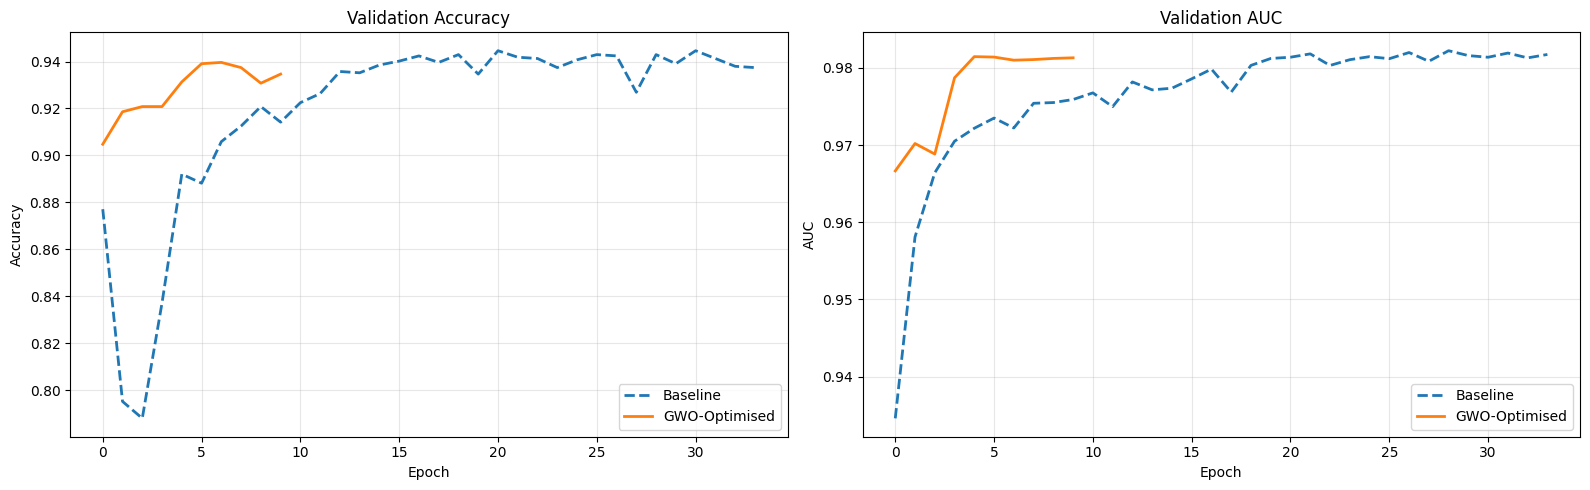

✓ Saved → ./plots/BiGRU_Conv_training_history.png


In [17]:
# ============================================================
# 11.1  Training History Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel in [
    (axes[0], "val_accuracy", "Accuracy"),
    (axes[1], "val_auc",      "AUC"),
]:
    ax.plot(baseline_history.history[metric],  label="Baseline",      lw=2, ls="--")
    ax.plot(optimised_history.history[metric], label="GWO-Optimised", lw=2)
    ax.set(title=f"Validation {ylabel}", xlabel="Epoch", ylabel=ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_training_history.png")
plt.savefig(_p, dpi=300, bbox_inches="tight"); plt.show()
print(f"\u2713 Saved \u2192 {_p}")

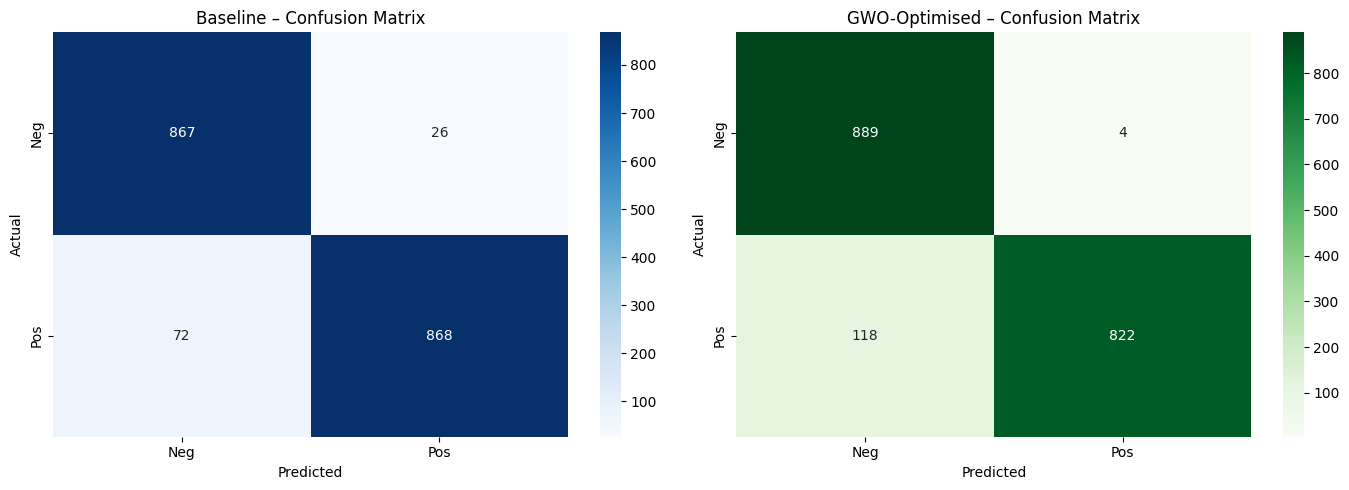

✓ Saved → ./plots/BiGRU_Conv_confusion_matrices.png


In [18]:
# ============================================================
# 11.2  Confusion Matrix Comparison
# ============================================================
cm_base = confusion_matrix(y_test, (baseline_model.predict(X_test, verbose=0) > 0.5).astype(int))
cm_opt  = confusion_matrix(y_test, (optimised_model.predict(X_test, verbose=0) > 0.5).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, cmap in [
    (axes[0], cm_base, "Baseline",      "Blues"),
    (axes[1], cm_opt,  "GWO-Optimised", "Greens"),
]:
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
    ax.set(title=f"{title} \u2013 Confusion Matrix",
           xlabel="Predicted", ylabel="Actual")

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrices.png")
plt.savefig(_p, dpi=300, bbox_inches="tight"); plt.show()
print(f"\u2713 Saved \u2192 {_p}")

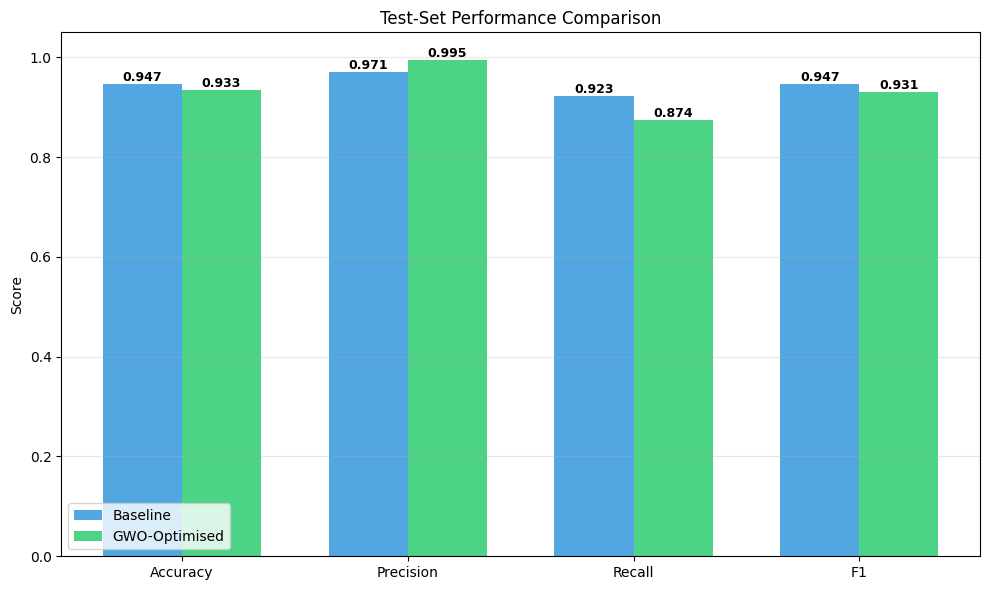

✓ Saved → ./plots/BiGRU_Conv_metrics_bar.png


In [19]:
# ============================================================
# 11.3  Metrics Bar Chart
# ============================================================
_mnames = ["Accuracy", "Precision", "Recall", "F1"]
x, w = np.arange(len(_mnames)), 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_b = ax.bar(x - w/2, [base_test[m] for m in _mnames], w,
                label="Baseline",      color="#3498db", alpha=0.85)
bars_o = ax.bar(x + w/2, [opt_test[m]  for m in _mnames], w,
                label="GWO-Optimised", color="#2ecc71", alpha=0.85)

for bars in (bars_b, bars_o):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set(xticks=x, xticklabels=_mnames, ylabel="Score",
       title="Test-Set Performance Comparison", ylim=[0, 1.05])
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_metrics_bar.png")
plt.savefig(_p, dpi=300, bbox_inches="tight"); plt.show()
print(f"\u2713 Saved \u2192 {_p}")

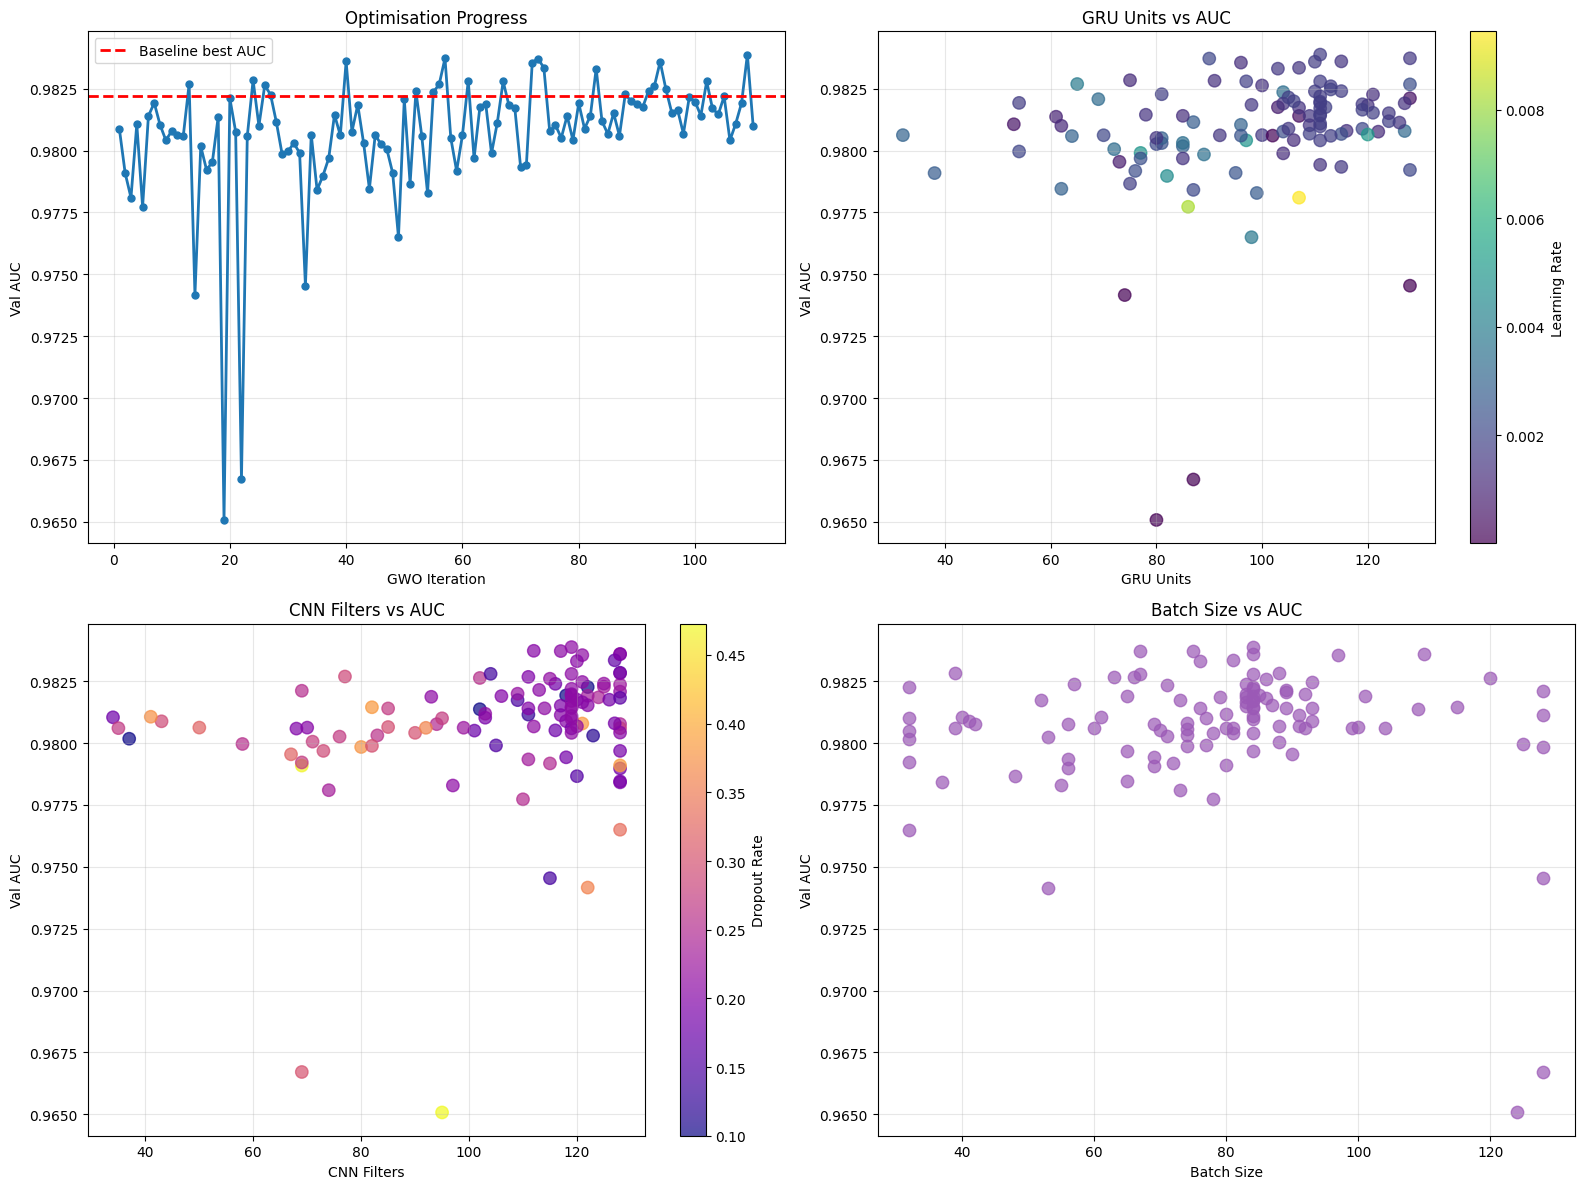

✓ Saved → ./plots/BiGRU_Conv_gwo_progress.png


In [20]:
# ============================================================
# 11.4  GWO Optimisation Progress  (4-panel)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# AUC per iteration
axes[0, 0].plot(gwo_log_df["iter"], gwo_log_df["val_auc"], marker="o", lw=2, ms=5)
axes[0, 0].axhline(y=max(baseline_history.history["val_auc"]),
                   color="r", ls="--", lw=2, label="Baseline best AUC")
axes[0, 0].set(xlabel="GWO Iteration", ylabel="Val AUC", title="Optimisation Progress")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# GRU units vs AUC
sc1 = axes[0, 1].scatter(gwo_log_df["gru_units"], gwo_log_df["val_auc"],
                          c=gwo_log_df["learning_rate"], cmap="viridis", s=80, alpha=0.7)
axes[0, 1].set(xlabel="GRU Units", ylabel="Val AUC", title="GRU Units vs AUC")
plt.colorbar(sc1, ax=axes[0, 1], label="Learning Rate")
axes[0, 1].grid(True, alpha=0.3)

# CNN filters vs AUC
sc2 = axes[1, 0].scatter(gwo_log_df["cnn_filters"], gwo_log_df["val_auc"],
                          c=gwo_log_df["dropout"], cmap="plasma", s=80, alpha=0.7)
axes[1, 0].set(xlabel="CNN Filters", ylabel="Val AUC", title="CNN Filters vs AUC")
plt.colorbar(sc2, ax=axes[1, 0], label="Dropout Rate")
axes[1, 0].grid(True, alpha=0.3)

# Batch size vs AUC
axes[1, 1].scatter(gwo_log_df["batch_size"], gwo_log_df["val_auc"],
                   color="#9b59b6", s=80, alpha=0.7)
axes[1, 1].set(xlabel="Batch Size", ylabel="Val AUC", title="Batch Size vs AUC")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_gwo_progress.png")
plt.savefig(_p, dpi=300, bbox_inches="tight"); plt.show()
print(f"\u2713 Saved \u2192 {_p}")